<a href="https://colab.research.google.com/github/GustavoHochgraf/training-eval-overlap/blob/master/notebooks/training_eval_overlap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training-Eval Overlap Analysis: Carolina × PoetaV2

Quantify how much of the PoetaV2 evaluation benchmark data appears in the Carolina corpus (pre-training data for a Qwen-based Portuguese LLM).

**Method:** Semantic similarity search using BAAI/bge-m3 embeddings + FAISS.

**Runtime:** ~3-5 hours on Colab T4 (full corpus). Quick test with 1K docs: ~2 min.

## Cell 1: Setup & Install

In [1]:
!pip install -q sentence-transformers faiss-cpu datasets pandas tqdm matplotlib seaborn

In [2]:
import os
import re
import json
import unicodedata
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import faiss
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Results directory (relative to notebook location)
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results will be saved to {RESULTS_DIR.resolve()}")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Results will be saved to /results
Device: cpu


In [3]:
# ── Configuration ──────────────────────────────────────────────────────────
# Set MAX_CAROLINA_DOCS to None for the full corpus, or an integer for a quick test.
MAX_CAROLINA_DOCS = 1000        # Quick test: 1000 docs (~2 min). Set to None for full run.
SIMILARITY_THRESHOLD = 0.85     # Cosine similarity threshold for "overlap"
TOP_K = 5                       # Nearest neighbors per query
EMBEDDING_MODEL = 'BAAI/bge-small-en-v1.5'  # Lightweight model (~33M params, fits Colab free)
BATCH_SIZE = 32
MIN_DOC_LENGTH = 50             # Minimum character length for Carolina docs
MAX_INSTANCES_PER_TASK = 500    # Cap per task to limit RAM. Set to None for all instances.
BOOTSTRAP_N = 10_000
BOOTSTRAP_CI = 0.95

## Cell 2: Download Carolina Corpus

In [4]:
from huggingface_hub import login
from pathlib import Path as _Path

def _load_env(path):
    """Read KEY=VALUE lines from a .env file, return dict."""
    env = {}
    try:
        for line in _Path(path).read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            key, _, value = line.partition("=")
            env[key.strip()] = value.strip()
    except FileNotFoundError:
        pass
    return env

# 1. Try local .env file (one level up from notebooks/)
HF_TOKEN = _load_env("../.env").get("HF_TOKEN")

# 2. Try Colab secrets
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

# 3. Try environment variable
if not HF_TOKEN:
    HF_TOKEN = os.environ.get("HF_TOKEN")

# 4. Last resort: interactive login
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Logged in with HF_TOKEN!")
else:
    print("No HF_TOKEN found.")
    print("Tip: On Colab, add HF_TOKEN to Secrets (key icon in left sidebar) to avoid pasting every time.")
    print("     Locally, create training-eval-overlap/.env with: HF_TOKEN=hf_xxx")
    from huggingface_hub import notebook_login
    notebook_login()

No HF_TOKEN found.
Tip: On Colab, add HF_TOKEN to Secrets (key icon in left sidebar) to avoid pasting every time.
     Locally, create training-eval-overlap/.env with: HF_TOKEN=hf_xxx


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [5]:
print("Loading Carolina corpus from g4me/corpus-carolina-v2...")
try:
    # Load the suggested dataset repository using the correct split 'corpus'
    dataset = load_dataset("g4me/corpus-carolina-v2", split="corpus", streaming=True)

    carolina_texts = []
    carolina_meta = []

    for i, example in enumerate(tqdm(dataset, desc="Loading Carolina")):
        if MAX_CAROLINA_DOCS is not None and i >= MAX_CAROLINA_DOCS:
            break

        text = example.get("text", "") or ""
        text_str = str(text).strip()
        if len(text_str) < MIN_DOC_LENGTH:
            continue

        carolina_texts.append(text_str)
        carolina_meta.append({
            "doc_id": str(i),
            "domain": example.get("taxonomy", "unknown"),
            "length": len(text_str),
        })

    print(f"\nCarolina corpus loaded: {len(carolina_texts):,} documents")

except Exception as e:
    print(f"Failed to load from g4me/corpus-carolina-v2: {e}")

Loading Carolina corpus from g4me/corpus-carolina-v2...


Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

Loading Carolina: 0it [00:00, ?it/s]


Carolina corpus loaded: 993 documents


## Cell 3: Download & Extract PoetaV2 Tasks

In [6]:
# Clone the PoetaV2 repository
!rm -rf /content/PoETaV2
!git clone --depth 1 https://github.com/PoETaV2/PoETaV2.git /content/PoETaV2
print("\nPoetaV2 repo cloned.")
!ls /content/PoETaV2/

Cloning into '/content/PoETaV2'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 129 (delta 15), reused 128 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 1.13 MiB | 14.31 MiB/s, done.
Resolving deltas: 100% (15/15), done.

PoetaV2 repo cloned.
configs		 description_conversation.json	lm_eval    scripts
conversation.py  description.json		main.py    setup.py
data		 docs				README.md  tokenization.py


In [7]:
# ── Task Source Registry ───────────────────────────────────────────────────
# Static mapping of every PoETaV2 evaluation task to its data source.
# Three source types: "hf" (HuggingFace datasets), "bigbench" (GitHub JSON),
# "custom" (per-task download logic).

import urllib.request
import csv
import io
import time
import gzip

poetav2_root = Path("/content/PoETaV2")

BIGBENCH_BASE_URL = (
    "https://raw.githubusercontent.com/ZanezZephyrs/"
    "temp_big_bench_json_tasks/refs/heads/main/tasks/"
)

TASK_SOURCES = {
    # ── HuggingFace tasks ──────────────────────────────────────────────────
    "assin_rte_greedy": {
        "type": "hf", "dataset_id": "assin2", "split": "test",
        "text_fields": {"question": "premise", "context": "hypothesis"},
    },
    "assin_sts_greedy": {
        "type": "hf", "dataset_id": "assin2", "split": "test",
        "text_fields": {"question": "premise", "context": "hypothesis"},
    },
    "agnews_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/ag_news_pt", "split": "test",
        "text_fields": {"question": "title", "context": "text"},
    },
    "boolq_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/boolq_pt", "split": "validation",
        "text_fields": {"question": "question", "context": "passage"},
    },
    "imdb_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/imdb_pt", "split": "test",
        "text_fields": {"question": "text"},
    },
    "sst2_pt_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/sst2_pt", "split": "validation",
        "text_fields": {"question": "text"},
    },
    "arc_challenge_greedy_pt": {
        "type": "hf", "dataset_id": "marlosb/ai2_arc-pt", "split": "test",
        "config": "ARC-Challenge",
        "text_fields": {"question": "question", "choices": "choices"},
    },
    "arc_easy_greedy_pt": {
        "type": "hf", "dataset_id": "marlosb/ai2_arc-pt", "split": "test",
        "config": "ARC-Easy",
        "text_fields": {"question": "question", "choices": "choices"},
    },
    "bluex_launch_version_": {
        "type": "hf", "dataset_id": "portuguese-benchmark-datasets/BLUEX",
        "split": "questions",
        "text_fields": {"question": "question"},
    },
    "storycloze_pt_greedy": {
        "type": "hf",
        "dataset_id": "portuguese-benchmark-datasets/story_cloze_pt",
        "split": "eval",
        "text_fields": {
            "context": ["input_sentence_1", "input_sentence_2",
                        "input_sentence_3", "input_sentence_4"],
            "question": "quiz1",
        },
    },
    "hatebr_binary_greedy": {
        "type": "hf", "dataset_id": "ruanchaves/hatebr", "split": "test",
        "text_fields": {"question": "instagram_comments"},
    },
    "enem_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/enem", "split": "train",
        "config": "2022",
        "text_fields": {"question": "question"},
    },
    "enem_2022_greedy": {
        "type": "hf", "dataset_id": "maritaca-ai/enem", "split": "train",
        "config": "2022",
        "text_fields": {"question": "question"},
    },
    "tweetsentbr_greedy": {
        "type": "hf", "dataset_id": "eduagarcia/tweetsentbr_fewshot", "split": "test",
        "text_fields": {"question": "sentence"},
    },
    "massive_greedy": {
        "type": "hf", "dataset_id": "AmazonScience/massive", "split": "test",
        "config": "pt-BR",
        "text_fields": {"question": "utt"},
    },

    # ── BigBench JSON tasks ────────────────────────────────────────────────
    # URL pattern: tasks/{DirName}/task.json (case-sensitive directory names)
    "broverbs_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "BRoverbs/task.json",
    },
    "broverbs_mc_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "BRoverbs_proverb_to_history/task.json",
    },
    "bigbench_pt_analogical_similarity_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "analogical_similarity/task.json",
    },
    "bigbench_pt_code_line_description_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "code_line_description/task.json",
    },
    "bigbench_pt_empirical_judgments_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "empirical_judgments/task.json",
    },
    "bigbench_pt_formal_fallacies_syllogisms_negation_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "formal_fallacies_syllogisms_negation/task.json",
    },
    "bigbench_pt_general_knowledge_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "general_knowledge/task.json",
    },
    "bigbench_pt_mathematical_induction_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "mathematical_induction/task.json",
    },
    "bigbench_pt_simple_ethical_questions_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "simple_ethical_questions/task.json",
    },
    "bigbench_pt_strategyqa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "strategyqa/task.json",
    },
    "bigbench_pt_vitaminc_fact_verification_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "vitaminc_fact_verification/task.json",
    },
    "bigbench_pt_causal_judgment_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "causal_judgment/task.json",
    },
    "bigbench_pt_cause_and_effect_two_sentences_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "cause_and_effect_two_sentences/task.json",
    },
    "bigbench_pt_social_iqa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "social_iqa/task.json",
    },
    "bigbench_pt_bbq_greedy": {
        "type": "bigbench",
        "json_url": [
            BIGBENCH_BASE_URL + "bbq/age_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/disability_status_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/gender_identity_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/nationality_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/physical_appearance_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/race_ethnicity_disambig/task.json",
            BIGBENCH_BASE_URL + "bbq/religion_disambig/task.json",
        ],
    },
    "ethics_commonsense_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "ethics_commonsense_test_hard/task.json",
    },
    "inferbr_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "inferbr/task.json",
    },
    "repro_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "repro/task.json",
    },
    "mina_br_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "MinaBR/task.json",
    },
    "math_mc_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "Math-mc/task.json",
    },
    "gsm8k_mc_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "gsm8k-mc/task.json",
    },
    "agieval_sat_math_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "sat_math/task.json",
    },
    "balanced_copa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "balanced_copa/task.json",
    },
    "logiqa_greedy": {
        "type": "bigbench",
        "json_url": BIGBENCH_BASE_URL + "logiQA/task.json",
    },

    # ── Custom tasks ───────────────────────────────────────────────────────
    "faquad_greedy": {
        "type": "custom",
        "handler": "faquad",
    },
    "mkqa_greedy": {
        "type": "custom",
        "handler": "mkqa",
    },
    "wsc285_pt_greedy": {
        "type": "custom",
        "handler": "wsc285_pt",
    },
    "pt_hate_speech_greedy": {
        "type": "custom",
        "handler": "pt_hate_speech",
    },
}

print(f"Task registry: {len(TASK_SOURCES)} tasks")
by_type = {}
for cfg in TASK_SOURCES.values():
    by_type[cfg["type"]] = by_type.get(cfg["type"], 0) + 1
for t, n in sorted(by_type.items()):
    print(f"  {t}: {n}")

Task registry: 43 tasks
  bigbench: 24
  custom: 4
  hf: 15


In [8]:
# ── Three Loader Functions ─────────────────────────────────────────────────

def load_hf_task(task_name, cfg):
    """Load a task from HuggingFace datasets. Returns list[EvalInstance]."""
    try:
        kwargs = {
            "path": cfg["dataset_id"],
            "split": cfg["split"],
            "trust_remote_code": True,
        }
        if "config" in cfg:
            kwargs["name"] = cfg["config"]

        ds = load_dataset(**kwargs)
        instances = []
        text_fields = cfg["text_fields"]

        for idx, example in enumerate(ds):
            question = ""
            context = ""
            answer = ""
            choices = []

            # Extract question field
            if "question" in text_fields:
                col = text_fields["question"]
                if isinstance(col, str):
                    question = str(example.get(col, ""))
                elif isinstance(col, list):
                    question = " ".join(str(example.get(c, "")) for c in col)

            # Extract context field (can be a single column or list of columns)
            if "context" in text_fields:
                col = text_fields["context"]
                if isinstance(col, list):
                    context = " ".join(str(example.get(c, "")) for c in col)
                else:
                    context = str(example.get(col, ""))

            # Extract choices (ARC format: nested dict with "text" and "label")
            if "choices" in text_fields:
                col = text_fields["choices"]
                raw = example.get(col, [])
                if isinstance(raw, dict) and "text" in raw:
                    choices = [str(t) for t in raw["text"]]
                elif isinstance(raw, list):
                    choices = [str(c) for c in raw]

            # Extract answer/label
            raw_answer = example.get("answer", example.get("label",
                         example.get("answerKey", "")))
            answer = str(raw_answer) if raw_answer is not None else ""

            inst = EvalInstance(
                task_name=task_name,
                instance_id=f"{task_name}_{idx}",
                split=cfg["split"],
                question=question,
                context=context,
                answer=answer,
                choices=choices,
            )
            if len(inst.search_text) >= MIN_DOC_LENGTH:
                instances.append(inst)

        return instances

    except Exception as e:
        print(f"    [WARN] {task_name}: {e}")
        return []


def _download_json(url):
    """Download and parse a JSON file from a URL."""
    req = urllib.request.Request(url, headers={"User-Agent": "PoETaV2-Analysis/1.0"})
    with urllib.request.urlopen(req, timeout=30) as resp:
        return json.loads(resp.read().decode("utf-8"))


def load_bigbench_task(task_name, cfg):
    """Load a BigBench-format JSON task. Returns list[EvalInstance]."""
    try:
        urls = cfg["json_url"]
        if isinstance(urls, str):
            urls = [urls]

        all_examples = []
        for url in urls:
            data = _download_json(url)
            all_examples.extend(data.get("examples", []))
            time.sleep(0.2)  # rate-limit politeness

        instances = []
        for idx, ex in enumerate(all_examples):
            question = str(ex.get("input", ""))
            target_scores = ex.get("target_scores", {})
            choices = list(target_scores.keys()) if target_scores else []
            # Answer is the key with score == 1
            answer = ""
            for k, v in target_scores.items():
                if v == 1:
                    answer = k
                    break

            # For tasks with empty input (e.g. cause_and_effect), use
            # the choices as the question text
            if not question.strip() and choices:
                question = " / ".join(choices)

            inst = EvalInstance(
                task_name=task_name,
                instance_id=f"{task_name}_{idx}",
                split="test",
                question=question,
                answer=answer,
                choices=choices,
            )
            if len(inst.search_text) >= MIN_DOC_LENGTH:
                instances.append(inst)

        return instances

    except Exception as e:
        print(f"    [WARN] {task_name}: {e}")
        return []


def load_custom_task(task_name, cfg, poetav2_root):
    """Load a custom task with per-task logic. Returns list[EvalInstance]."""
    handler = cfg["handler"]
    instances = []

    try:
        if handler == "faquad":
            url = ("https://raw.githubusercontent.com/liafacom/faquad/"
                   "master/data/dataset.json")
            data = _download_json(url)
            idx = 0
            for article in data.get("data", []):
                for para in article.get("paragraphs", []):
                    context = para.get("context", "")
                    for qa in para.get("qas", []):
                        question = qa.get("question", "")
                        answers = qa.get("answers", [])
                        answer = answers[0]["text"] if answers else ""
                        inst = EvalInstance(
                            task_name=task_name,
                            instance_id=f"{task_name}_{idx}",
                            split="test",
                            question=question,
                            context=context,
                            answer=answer,
                        )
                        if len(inst.search_text) >= MIN_DOC_LENGTH:
                            instances.append(inst)
                        idx += 1

        elif handler == "mkqa":
            # MKQA is a gzipped JSONL file
            url = ("https://raw.githubusercontent.com/apple/ml-mkqa/"
                   "main/dataset/mkqa.jsonl.gz")
            req = urllib.request.Request(url, headers={
                "User-Agent": "PoETaV2-Analysis/1.0"})
            with urllib.request.urlopen(req, timeout=120) as resp:
                raw = gzip.decompress(resp.read())
            for line in raw.decode("utf-8").splitlines():
                if not line.strip():
                    continue
                row = json.loads(line)
                queries = row.get("queries", {})
                answers = row.get("answers", {})
                pt_query = queries.get("pt", "")
                pt_answers = answers.get("pt", [])
                answer_text = ""
                if pt_answers and isinstance(pt_answers, list):
                    first = pt_answers[0]
                    if isinstance(first, dict):
                        answer_text = str(first.get("text", ""))
                    else:
                        answer_text = str(first)

                if pt_query:
                    inst = EvalInstance(
                        task_name=task_name,
                        instance_id=f"{task_name}_{len(instances)}",
                        split="test",
                        question=pt_query,
                        answer=answer_text,
                    )
                    if len(inst.search_text) >= MIN_DOC_LENGTH:
                        instances.append(inst)

        elif handler == "wsc285_pt":
            url = ("https://raw.githubusercontent.com/gabimelo/portuguese_wsc/"
                   "master/data/processed/portuguese_wsc.json")
            data = _download_json(url)
            items = data if isinstance(data, list) else data.get(
                "data", data.get("examples", []))
            for idx, item in enumerate(items):
                if isinstance(item, dict):
                    text = item.get("text", item.get("sentence", str(item)))
                    answer = str(item.get("answer", item.get("label", "")))
                else:
                    text = str(item)
                    answer = ""
                inst = EvalInstance(
                    task_name=task_name,
                    instance_id=f"{task_name}_{idx}",
                    split="test",
                    question=str(text),
                    answer=answer,
                )
                if len(inst.search_text) >= MIN_DOC_LENGTH:
                    instances.append(inst)

        elif handler == "pt_hate_speech":
            url = ("https://raw.githubusercontent.com/paulafortuna/"
                   "Portuguese-Hate-Speech-Dataset/master/"
                   "2019-05-28_portuguese_hate_speech_binary_classification.csv")
            req = urllib.request.Request(url, headers={
                "User-Agent": "PoETaV2-Analysis/1.0"})
            with urllib.request.urlopen(req, timeout=30) as resp:
                content = resp.read().decode("utf-8")
            reader = csv.DictReader(io.StringIO(content))
            for idx, row in enumerate(reader):
                text = row.get("text", "")
                inst = EvalInstance(
                    task_name=task_name,
                    instance_id=f"{task_name}_{idx}",
                    split="test",
                    question=str(text),
                    answer=str(row.get("hatespeech_comb", "")),
                )
                if len(inst.search_text) >= MIN_DOC_LENGTH:
                    instances.append(inst)

        else:
            print(f"    [WARN] {task_name}: unknown handler '{handler}'")

    except Exception as e:
        print(f"    [WARN] {task_name}: {e}")

    return instances

print("Loader functions defined: load_hf_task, load_bigbench_task, load_custom_task")

Loader functions defined: load_hf_task, load_bigbench_task, load_custom_task


In [9]:
@dataclass
class EvalInstance:
    """A single evaluation instance from a PoetaV2 task."""
    task_name: str
    instance_id: str
    split: str = "test"
    question: str = ""
    context: str = ""
    answer: str = ""
    choices: list = field(default_factory=list)

    @property
    def search_text(self) -> str:
        """Concatenate question + context for embedding search."""
        parts = [self.question, self.context]
        return " ".join(p for p in parts if p.strip())

    @property
    def all_text_fields(self) -> list:
        fields = [self.question, self.context, self.answer] + self.choices
        return [f for f in fields if f.strip()]

In [10]:
# ── Load All PoETaV2 Tasks ─────────────────────────────────────────────────

import random

LOADERS = {
    "hf": lambda name, cfg: load_hf_task(name, cfg),
    "bigbench": lambda name, cfg: load_bigbench_task(name, cfg),
    "custom": lambda name, cfg: load_custom_task(name, cfg, poetav2_root),
}

all_instances = []
failed_tasks = []

print(f"Loading {len(TASK_SOURCES)} tasks...")
if MAX_INSTANCES_PER_TASK:
    print(f"  (capped at {MAX_INSTANCES_PER_TASK} instances per task)\n")

for task_name, cfg in TASK_SOURCES.items():
    loader = LOADERS[cfg["type"]]
    instances = loader(task_name, cfg)

    # Cap instances per task to limit memory
    if instances and MAX_INSTANCES_PER_TASK and len(instances) > MAX_INSTANCES_PER_TASK:
        random.seed(42)
        instances = random.sample(instances, MAX_INSTANCES_PER_TASK)

    if instances:
        all_instances.extend(instances)
        print(f"  {task_name}: {len(instances)} instances")
    else:
        failed_tasks.append(task_name)
        print(f"  {task_name}: 0 instances (FAILED)")

eval_instances = all_instances

print(f"\n{'='*60}")
print(f"Total: {len(eval_instances):,} evaluation instances from "
      f"{len(TASK_SOURCES) - len(failed_tasks)}/{len(TASK_SOURCES)} tasks")

if failed_tasks:
    print(f"\nFailed tasks ({len(failed_tasks)}):")
    for t in failed_tasks:
        print(f"  - {t}")

# Build DataFrame for display
instance_df = pd.DataFrame([
    {"task_name": i.task_name, "instance_id": i.instance_id,
     "question": i.question[:100], "context": i.context[:100],
     "answer": str(i.answer)[:50]}
    for i in eval_instances
])

# Per-task counts
if len(instance_df) > 0:
    task_counts = instance_df['task_name'].value_counts().sort_index()
    print(f"\n{len(task_counts)} tasks loaded:")
    print(task_counts.to_string())
else:
    task_counts = pd.Series(dtype=int)
    print("\nWARNING: No instances loaded. Check errors above.")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'assin2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'assin2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading 43 tasks...
  (capped at 500 instances per task)



`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'assin2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'assin2' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  assin_rte_greedy: 500 instances


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'maritaca-ai/ag_news_pt' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'maritaca-ai/ag_news_pt' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'maritaca-ai/boolq_pt' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_

...

  enem_greedy: 180 instances


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'eduagarcia/tweetsentbr_fewshot' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'eduagarcia/tweetsentbr_fewshot' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  enem_2022_greedy: 180 instances


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AmazonScience/massive' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AmazonScience/massive' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  tweetsentbr_greedy: 500 instances
    [WARN] massive_greedy: Dataset scripts are no longer supported, but found massive.py
  massive_greedy: 0 instances (FAILED)
  broverbs_greedy: 194 instances
  broverbs_mc_greedy: 27 instances
  bigbench_pt_analogical_similarity_greedy: 300 instances
  bigbench_pt_code_line_description_greedy: 44 instances
  bigbench_pt_empirical_judgments_greedy: 39 instances
  bigbench_pt_formal_fallacies_syllogisms_negation_greedy: 300 instances
  bigbench_pt_general_knowledge_greedy: 14 instances
  bigbench_pt_mathematical_induction_greedy: 68 instances
  bigbench_pt_simple_ethical_questions_greedy: 115 instances
  bigbench_pt_strategyqa_greedy: 216 instances
  bigbench_pt_vitaminc_fact_verification_greedy: 300 instances
  bigbench_pt_causal_judgment_greedy: 190 instances
  bigbench_pt_cause_and_effect_two_sentences_greedy: 42 instances
  bigbench_pt_social_iqa_greedy: 300 instances
  bigbench_pt_bbq_greedy: 500 instances
  ethics_commonsense_greedy: 216 insta

## Cell 4: Embed Carolina with bge-m3

In [11]:
print(f"Loading embedding model: {EMBEDDING_MODEL}")
model = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
embedding_dim = model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {embedding_dim}")
print(f"Model loaded on {DEVICE}")

Loading embedding model: BAAI/bge-small-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384
Model loaded on cpu


In [12]:
# Encode Carolina documents in batches
# For large corpora, process in chunks to manage RAM

CHUNK_SIZE = 50_000  # Process this many docs at a time for RAM management

def build_faiss_index_incremental(texts, model, batch_size=64, chunk_size=50_000):
    """Build FAISS index incrementally to manage RAM."""
    dim = model.get_sentence_embedding_dimension()

    # Use GPU FAISS if available
    try:
        res = faiss.StandardGpuResources()
        index_flat = faiss.IndexFlatIP(dim)
        index = faiss.index_cpu_to_gpu(res, 0, index_flat)
        print("Using FAISS GPU index")
    except Exception:
        index = faiss.IndexFlatIP(dim)
        print("Using FAISS CPU index")

    n_chunks = (len(texts) + chunk_size - 1) // chunk_size

    for chunk_idx in range(n_chunks):
        start = chunk_idx * chunk_size
        end = min(start + chunk_size, len(texts))
        chunk_texts = texts[start:end]

        print(f"\nEncoding chunk {chunk_idx + 1}/{n_chunks} ({start:,}-{end:,})...")
        embeddings = model.encode(
            chunk_texts,
            batch_size=batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        embeddings = np.array(embeddings, dtype=np.float32)
        index.add(embeddings)
        print(f"  Index size: {index.ntotal:,} vectors")

    return index


print(f"Encoding {len(carolina_texts):,} Carolina documents...")
carolina_index = build_faiss_index_incremental(
    carolina_texts, model, batch_size=BATCH_SIZE, chunk_size=CHUNK_SIZE
)
print(f"\nFAISS index built: {carolina_index.ntotal:,} vectors, dim={embedding_dim}")

Encoding 993 Carolina documents...
Using FAISS CPU index

Encoding chunk 1/1 (0-993)...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

  Index size: 993 vectors

FAISS index built: 993 vectors, dim=384


In [14]:
# Optional: save index
try:
    index_path = RESULTS_DIR / "faiss_index"
    index_path.mkdir(parents=True, exist_ok=True)

    # Convert GPU index to CPU for saving
    try:
        cpu_index = faiss.index_gpu_to_cpu(carolina_index)
    except Exception:
        cpu_index = carolina_index

    faiss.write_index(cpu_index, str(index_path / "carolina.faiss"))
    np.save(index_path / "doc_ids.npy", np.array([m['doc_id'] for m in carolina_meta], dtype=object))
    print(f"Index saved to {index_path}")
except Exception as e:
    print(f"Could not save index: {e}")

Index saved to ../results/faiss_index


## Cell 5: Search for Overlap

In [15]:
# Embed each PoetaV2 instance (question + context concatenated)
query_texts = [inst.search_text for inst in eval_instances]
print(f"Encoding {len(query_texts)} PoetaV2 queries...")

query_embeddings = model.encode(
    query_texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
)
query_embeddings = np.array(query_embeddings, dtype=np.float32)
print(f"Query embeddings shape: {query_embeddings.shape}")

Encoding 11409 PoetaV2 queries...


Batches:   0%|          | 0/357 [00:00<?, ?it/s]

Query embeddings shape: (11409, 384)


In [16]:
# FAISS top-K nearest neighbor search
print(f"Searching FAISS index (top-{TOP_K})...")
scores, indices = carolina_index.search(query_embeddings, TOP_K)
print(f"Search complete. Scores shape: {scores.shape}")

# Build results DataFrame
results = []
for q_idx in range(len(eval_instances)):
    inst = eval_instances[q_idx]
    top1_sim = float(scores[q_idx][0])
    top1_doc_idx = int(indices[q_idx][0])

    top1_text = carolina_texts[top1_doc_idx] if top1_doc_idx >= 0 else ""
    top1_doc_id = carolina_meta[top1_doc_idx]['doc_id'] if top1_doc_idx >= 0 else ""

    results.append({
        'task_name': inst.task_name,
        'instance_id': inst.instance_id,
        'query_text': inst.search_text[:200],
        'top1_similarity': top1_sim,
        'top1_doc_id': top1_doc_id,
        'top1_doc_text': top1_text[:300],
        'overlap': top1_sim >= SIMILARITY_THRESHOLD,
        # Store all top-K similarities for analysis
        'top5_similarities': [float(scores[q_idx][k]) for k in range(TOP_K) if indices[q_idx][k] >= 0],
    })

results_df = pd.DataFrame(results)
print(f"\nResults: {len(results_df)} instances")
print(f"Overlapping (sim >= {SIMILARITY_THRESHOLD}): {results_df['overlap'].sum()} ({results_df['overlap'].mean()*100:.1f}%)")

Searching FAISS index (top-5)...
Search complete. Scores shape: (11409, 5)

Results: 11409 instances
Overlapping (sim >= 0.85): 15 (0.1%)


## Cell 6: Results & Analysis

In [17]:
# ── Per-task overlap table ─────────────────────────────────────────────────

def bootstrap_ci(contaminated, total, n_bootstrap=10_000, ci=0.95, seed=42):
    """Compute bootstrap confidence interval for a contamination rate."""
    if total == 0:
        return 0.0, 0.0, 0.0
    rng = np.random.default_rng(seed)
    labels = np.array([1] * contaminated + [0] * (total - contaminated))
    boot_rates = np.array([
        rng.choice(labels, size=total, replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    alpha = (1 - ci) / 2
    return (
        contaminated / total,
        float(np.percentile(boot_rates, 100 * alpha)),
        float(np.percentile(boot_rates, 100 * (1 - alpha))),
    )


task_summary = []
for task_name, group in results_df.groupby('task_name'):
    total = len(group)
    overlapping = group['overlap'].sum()
    rate = overlapping / total if total > 0 else 0.0
    mean_sim = group['top1_similarity'].mean()
    _, ci_lo, ci_hi = bootstrap_ci(int(overlapping), total, BOOTSTRAP_N, BOOTSTRAP_CI)

    task_summary.append({
        'Task': task_name,
        'Total': total,
        'Overlapping': int(overlapping),
        'Rate (%)': rate * 100,
        'Mean Sim': mean_sim,
        'CI Lower': ci_lo * 100,
        'CI Upper': ci_hi * 100,
    })

summary_df = pd.DataFrame(task_summary).sort_values('Rate (%)', ascending=False)

# Overall row
total_all = results_df.shape[0]
overlap_all = results_df['overlap'].sum()
_, ci_lo_all, ci_hi_all = bootstrap_ci(int(overlap_all), total_all, BOOTSTRAP_N, BOOTSTRAP_CI)
overall_row = pd.DataFrame([{
    'Task': 'OVERALL',
    'Total': total_all,
    'Overlapping': int(overlap_all),
    'Rate (%)': overlap_all / total_all * 100 if total_all else 0,
    'Mean Sim': results_df['top1_similarity'].mean(),
    'CI Lower': ci_lo_all * 100,
    'CI Upper': ci_hi_all * 100,
}])
display_df = pd.concat([summary_df, overall_row], ignore_index=True)

print("Per-Task Overlap Summary")
print("=" * 90)
print(display_df.to_string(index=False, float_format='%.2f'))

Per-Task Overlap Summary
                                                   Task  Total  Overlapping  Rate (%)  Mean Sim  CI Lower  CI Upper
                                            enem_greedy    180            2      1.11      0.78      0.00      2.78
                                       enem_2022_greedy    180            2      1.11      0.78      0.00      2.78
            bigbench_pt_simple_ethical_questions_greedy    115            1      0.87      0.77      0.00      2.61
                                  bluex_launch_version_    500            3      0.60      0.76      0.00      1.40
                                         mina_br_greedy    500            2      0.40      0.78      0.00      1.00
                                       assin_sts_greedy    500            1      0.20      0.78      0.00      0.60
                                            mkqa_greedy    500            1      0.20      0.75      0.00      0.60
                                  pt_hate_speec

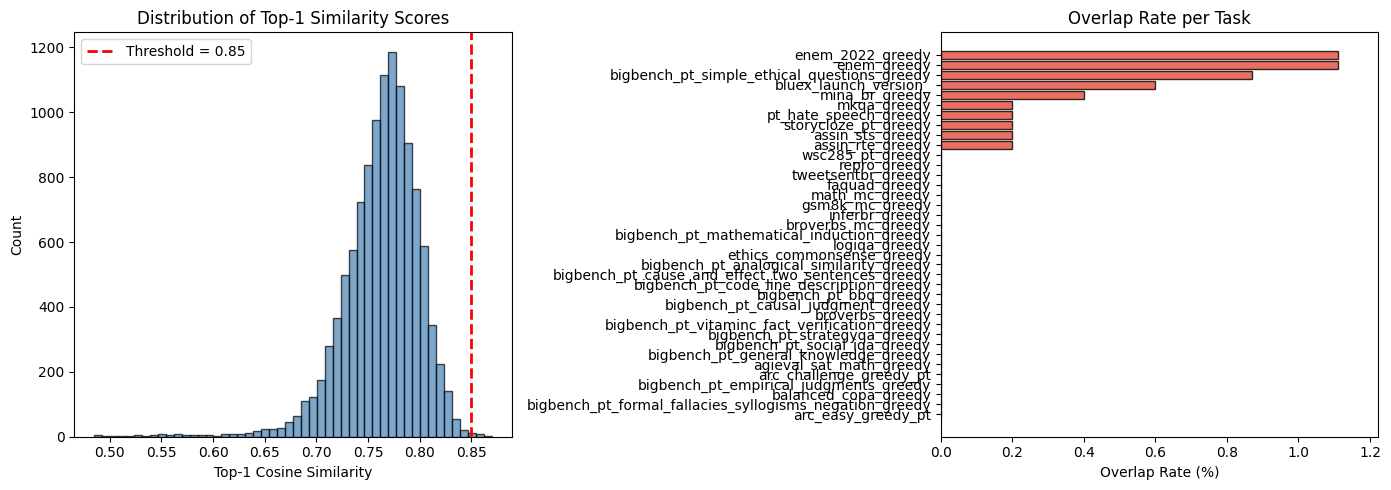

Figure saved to ../results/overlap_distribution.png


In [18]:
# ── Similarity distribution histogram ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all top-1 similarities
ax = axes[0]
ax.hist(results_df['top1_similarity'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(SIMILARITY_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {SIMILARITY_THRESHOLD}')
ax.set_xlabel('Top-1 Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Distribution of Top-1 Similarity Scores')
ax.legend()

# Overlap rate per task (bar chart)
ax = axes[1]
plot_df = summary_df.sort_values('Rate (%)', ascending=True)
colors = ['#e74c3c' if r > 0 else '#2ecc71' for r in plot_df['Rate (%)']]
ax.barh(plot_df['Task'], plot_df['Rate (%)'], color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Overlap Rate (%)')
ax.set_title('Overlap Rate per Task')
ax.set_xlim(0, max(plot_df['Rate (%)'].max() * 1.1, 1))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'overlap_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved to {RESULTS_DIR / 'overlap_distribution.png'}")

/tmp/ipykernel_57582/1985459093.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


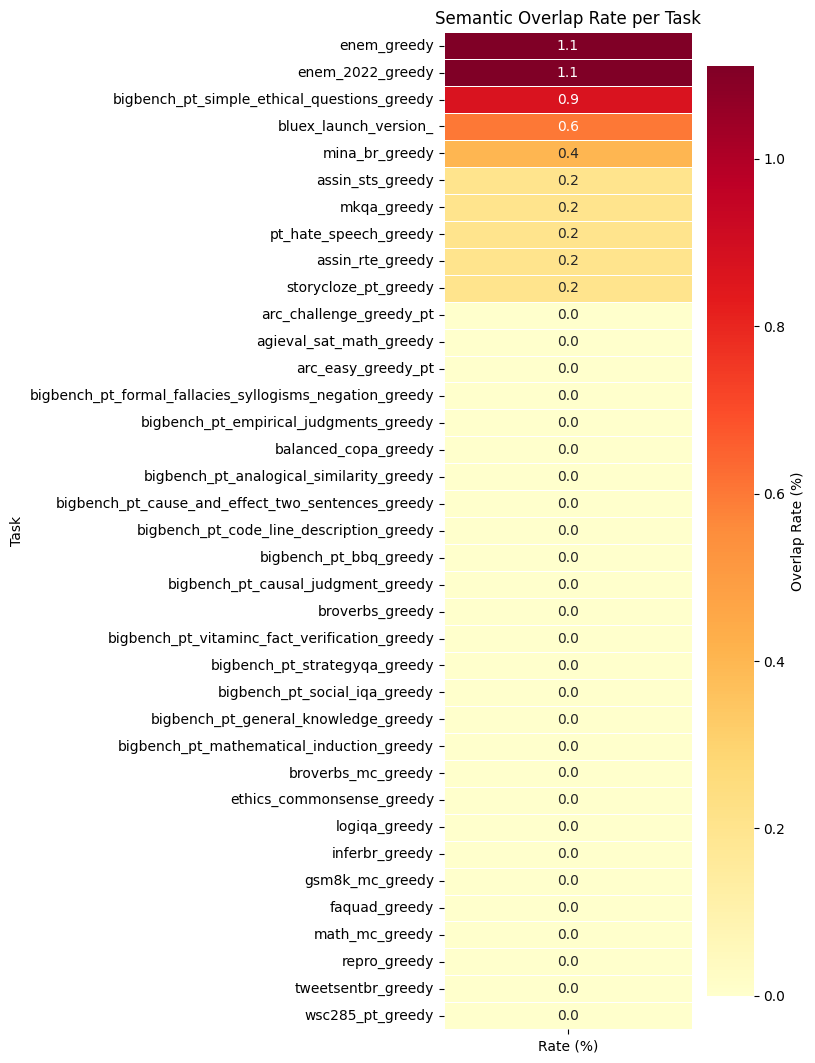

Heatmap saved to ../results/overlap_heatmap.png


In [19]:
# ── Heatmap: overlap rate per task ─────────────────────────────────────────

if len(summary_df) > 1:
    fig, ax = plt.subplots(figsize=(4, max(6, len(summary_df) * 0.35)))
    heatmap_data = summary_df.set_index('Task')[['Rate (%)']]
    sns.heatmap(
        heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
        cbar_kws={'label': 'Overlap Rate (%)'},
        linewidths=0.5, ax=ax
    )
    ax.set_title('Semantic Overlap Rate per Task')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'overlap_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Heatmap saved to {RESULTS_DIR / 'overlap_heatmap.png'}")

In [20]:
# ── Top-N most suspicious matches (manual inspection) ──────────────────────

TOP_N_INSPECT = 20

suspicious = results_df.nlargest(TOP_N_INSPECT, 'top1_similarity')
print(f"Top-{TOP_N_INSPECT} most similar matches (for manual inspection):")
print("=" * 100)
for _, row in suspicious.iterrows():
    print(f"\n{'─' * 80}")
    print(f"Task: {row['task_name']} | Instance: {row['instance_id']} | Similarity: {row['top1_similarity']:.4f}")
    print(f"Query:    {row['query_text'][:200]}")
    print(f"Matched:  {row['top1_doc_text'][:200]}")

Top-20 most similar matches (for manual inspection):

────────────────────────────────────────────────────────────────────────────────
Task: bluex_launch_version_ | Instance: bluex_launch_version__328 | Similarity: 0.8696
Query:    Texto para a questão:

Leusipo perguntou o que eu tinha ido fazer na aldeia. Preferi achar que o tom era amistoso e, no meu *paternalismo* ingênuo, comecei a lhe explicar o que era um romance. Eu tent
Matched:  AMlGOS PARA SEMPRE AIguém escreveu: "Todo ser vivo no mundo tem a proteção de um anjo." E eu acredito muito nessa frase de sabedoria. Em um dia cIaro de verão... era um dos Iugares mais Iindos da terr

────────────────────────────────────────────────────────────────────────────────
Task: bluex_launch_version_ | Instance: bluex_launch_version__329 | Similarity: 0.8631
Query:    Como justificar que somos uma humanidade, se mais 
de 70% estão totalmente alienados do mínimo exercício 
de ser? A modernização jogou essa gente do campo e 
da floresta para vi

In [21]:
# ── Export results to CSV ──────────────────────────────────────────────────

# Full results
export_df = results_df.drop(columns=['top5_similarities'])
csv_path = RESULTS_DIR / 'overlap_results_full.csv'
export_df.to_csv(csv_path, index=False)
print(f"Full results saved to {csv_path}")

# Summary table
summary_csv_path = RESULTS_DIR / 'overlap_summary_per_task.csv'
display_df.to_csv(summary_csv_path, index=False)
print(f"Summary table saved to {summary_csv_path}")

Full results saved to ../results/overlap_results_full.csv
Summary table saved to ../results/overlap_summary_per_task.csv


## Cell 7: LaTeX Table

In [22]:
# ── Generate publication-ready LaTeX table with bootstrap CIs ──────────────

def generate_latex_table(summary_df, results_df, n_bootstrap=10_000, ci=0.95):
    """Generate a LaTeX table with per-task overlap rates and bootstrap CIs."""
    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\caption{Semantic overlap rates: Carolina corpus $\times$ PoetaV2 benchmarks.}",
        r"\label{tab:semantic-overlap}",
        r"\begin{tabular}{lrrrr}",
        r"\toprule",
        r"Task & $N$ & Overlap (\%) & Mean Sim & 95\% CI \\",
        r"\midrule",
    ]

    for _, row in summary_df.iterrows():
        task = row['Task'].replace('_', r'\_')
        lines.append(
            f"{task} & {row['Total']:.0f} & "
            f"{row['Rate (%)']:.1f} & {row['Mean Sim']:.3f} & "
            f"[{row['CI Lower']:.1f}, {row['CI Upper']:.1f}] \\\\"
        )

    # Overall row
    total_n = results_df.shape[0]
    total_overlap = results_df['overlap'].sum()
    rate = total_overlap / total_n * 100 if total_n else 0
    mean_sim = results_df['top1_similarity'].mean()
    _, ci_lo, ci_hi = bootstrap_ci(int(total_overlap), total_n, n_bootstrap, ci)

    lines.append(r"\midrule")
    lines.append(
        f"\\textbf{{Overall}} & {total_n} & "
        f"{rate:.1f} & {mean_sim:.3f} & "
        f"[{ci_lo * 100:.1f}, {ci_hi * 100:.1f}] \\\\"
    )

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ]

    return "\n".join(lines)


latex_table = generate_latex_table(summary_df, results_df, BOOTSTRAP_N, BOOTSTRAP_CI)

# Save to file
latex_path = RESULTS_DIR / 'overlap_table.tex'
latex_path.write_text(latex_table, encoding='utf-8')
print(f"LaTeX table saved to {latex_path}")

# Display for copy-paste
print("\n" + "=" * 80)
print("Copy-paste the following into your paper:")
print("=" * 80)
print(latex_table)

LaTeX table saved to ../results/overlap_table.tex

Copy-paste the following into your paper:
\begin{table}[ht]
\centering
\caption{Semantic overlap rates: Carolina corpus $\times$ PoetaV2 benchmarks.}
\label{tab:semantic-overlap}
\begin{tabular}{lrrrr}
\toprule
Task & $N$ & Overlap (\%) & Mean Sim & 95\% CI \\
\midrule
enem\_greedy & 180 & 1.1 & 0.776 & [0.0, 2.8] \\
enem\_2022\_greedy & 180 & 1.1 & 0.776 & [0.0, 2.8] \\
bigbench\_pt\_simple\_ethical\_questions\_greedy & 115 & 0.9 & 0.772 & [0.0, 2.6] \\
bluex\_launch\_version\_ & 500 & 0.6 & 0.759 & [0.0, 1.4] \\
mina\_br\_greedy & 500 & 0.4 & 0.780 & [0.0, 1.0] \\
assin\_sts\_greedy & 500 & 0.2 & 0.783 & [0.0, 0.6] \\
mkqa\_greedy & 500 & 0.2 & 0.750 & [0.0, 0.6] \\
pt\_hate\_speech\_greedy & 500 & 0.2 & 0.782 & [0.0, 0.6] \\
assin\_rte\_greedy & 500 & 0.2 & 0.783 & [0.0, 0.6] \\
storycloze\_pt\_greedy & 500 & 0.2 & 0.789 & [0.0, 0.6] \\
arc\_challenge\_greedy\_pt & 500 & 0.0 & 0.751 & [0.0, 0.0] \\
agieval\_sat\_math\_greedy & 218 &